We study feature transformation because raw data is often not in the best form for machine learning models. Transforming features helps models learn patterns more easily, accurately, and efficiently.

Here are the main reasons:

✅ 1. Improve model performance

Some algorithms (like linear regression, SVM, neural networks) work better when data follows certain patterns (e.g., linear relationship, normal distribution).
Feature transformation reshapes data so the model can learn better.

👉 Example: Taking log of income instead of raw income when values are highly skewed.

✅ 2. Handle non-linear relationships

Sometimes input and output are not linearly related.
Feature transformation helps convert non-linear relationships into linear ones.

👉 Example:
If
* y = 2x^2 + 5

you can transform feature to 

* y = 2x + 5

 to make model learn easily.

✅ 3. Normalize or scale data

Different features may have very different ranges (age vs salary vs distance).
Some models are sensitive to scale (KNN, gradient descent, SVM).

Feature transformation helps make features comparable.

👉 Methods:

Standardization (z-score)

Min-max scaling

✅ 4. Reduce skewness & make distribution normal

Many models assume normally distributed data.
Transformations like log, square root, or Box-Cox reduce skewness.

👉 Example: House prices often right-skewed → apply log transform.

✅ 5. Reduce noise or improve interpretability

Some transformations make data simpler or easier to understand.

👉 Example:
Converting date → year, month, day
Creating ratio features (income / expenses)

✅ 6. Improve convergence speed in training

Better scaled and structured features help optimization algorithms converge faster.

🧠 Simple summary

Feature transformation = making data more suitable for learning.
It helps models learn faster, predict better, and avoid errors caused by poor data structure.

𝗧𝗿𝗮𝗻𝘀𝗳𝗼𝗿𝗺𝗮𝘁𝗶𝗼𝗻 𝗼𝗳 𝗙𝗲𝗮𝘁𝘂𝗿𝗲𝘀

why Transformation of Feature Are Required

1. Linear Regression---Grandient---Global Minima
2. Algorithms like KNN, K Means, Hieraichal Clustering---Eucledian Distance


Every points has some vectors and Direction

Deep Learning Techniques(Standardization, Scalling) 1.ANN--->Global Minima, Gradient 2, CNN 3. RNN

0-255 pixels

Types of Transformation

1. Normalization And Standardization
2. Scaling to Minimum And Maximum values
3. Scaling To Mwdian and Quantiles
4. Guassian Transformation
5. Logarithmic Transformation
6. Reciprocal Transformation
7. Square Root Transformation
8. Exponential Transformation 
9. Box Cox Transformation

Standardization(Why standardization?)

Standardization comes into picture when feature of input data set have large differences between their ranges, or simply when they are measured in different measurement units (e.g., Pounds, Meters, Miles … etc).

We try to bring all the variables or features to a similar scale. standarisation means centering the variable at zero. z=(x-x_mean)/std

In [2]:
import pandas as pd 

In [3]:
df=pd.read_csv('titanic.csv',usecols=['Pclass','Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [5]:
df[df.isnull()].columns

Index(['Survived', 'Pclass', 'Age', 'Fare'], dtype='object')

In [6]:
df.isnull().sum()

Survived      0
Pclass        0
Age         177
Fare          0
dtype: int64

In [7]:
df[df['Age'].isnull()].index

Index([  5,  17,  19,  26,  28,  29,  31,  32,  36,  42,
       ...
       832, 837, 839, 846, 849, 859, 863, 868, 878, 888],
      dtype='int64', length=177)

In [8]:
df['Age'].fillna(df.Age.median(),inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_21544\2569459057.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df.Age.median(),inplace=True)


In [9]:
df.isnull().sum()

Survived    0
Pclass      0
Age         0
Fare        0
dtype: int64

Let’s understand clearly and logically why we usually do NOT standardize the dependent variable (y).

🎯 First understand model roles

In machine learning:

👉 Independent variables (X) = inputs → model uses them to learn patterns
👉 Dependent variable (y) = output → model tries to predict this

So:

X helps the model learn

y is the answer the model must predict

✅ Why we standardize X (features)?

Because features can have different scales.

Example:

Height = 170 cm

Salary = ₹80,000

Salary is much bigger → model may give it more importance unfairly.
So we standardize X to make features fair and comparable.

✔ This helps learning.

❌ Why we DON’T standardize y (target)?
🔹 Reason 1 — y is the meaning of prediction

The model must predict real-world values.

Example:
Predict house price = ₹50,00,000

If you standardize y → model predicts something like:
👉 1.37 or -0.85

This number has no real meaning unless you convert it back.

So standardizing y makes interpretation harder.

🔹 Reason 2 — Model is not comparing y with other features

Features compete with each other → need scaling
Target does NOT compete → no need scaling

Model only tries to match prediction to y.
Scale of y does not affect learning in most models.

🔹 Reason 3 — In classification it breaks labels

Example labels:

0 = No

1 = Yes

If standardized → becomes:

-0.71, 1.23 etc.

These are not class labels anymore ❌
Model gets confused.

So classification → NEVER scale y.

🔹 Reason 4 — Extra complexity (inverse transform needed)

If you scale y, after prediction you must convert back:

scaled prediction → inverse scaling → real value

Extra step → more chances of mistakes.

✅ When CAN we standardize y?

Only in special cases:

✔ Neural networks
✔ Very large target values (like millions or billions)
✔ Some advanced regression optimization

But then we MUST reverse scaling after prediction.

🧠 Super simple analogy

Teacher checking exam marks:

Students’ study hours vary a lot → adjust them (scale X)
But final marks are real → don’t change them (keep y real)

⭐ Interview perfect answer

We standardize independent variables because different feature scales affect model learning. The dependent variable represents the actual value to predict, so scaling it is usually unnecessary and may make interpretation difficult. In classification, scaling target labels breaks class meaning.

In [10]:
df

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500
...,...,...,...,...
886,0,2,27.0,13.0000
887,1,1,19.0,30.0000
888,0,3,28.0,23.4500
889,1,1,26.0,30.0000


⭐ Interview answer (short)

The dependent variable is the output we want to predict, and independent variables are the input features used to predict it. We identify them based on the problem objective or target column in the dataset.

In [11]:
### Independent and dependent feature 
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [12]:
x

,Pclass,Age,Fare
0,3,22.0,7.2500
1,1,38.0,71.2833
2,3,26.0,7.9250
3,1,35.0,53.1000
4,3,35.0,8.0500
...,...,...,...
886,2,27.0,13.0000
887,1,19.0,30.0000
888,3,28.0,23.4500
889,1,26.0,30.0000


In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.33,random_state=42)

In [27]:
x_train

,Pclass,Age,Fare
6,1,54.0,51.8625
718,3,28.0,15.5000
685,2,25.0,41.5792
73,3,26.0,14.4542
882,3,22.0,10.5167
...,...,...,...
106,3,21.0,7.6500
270,1,28.0,31.0000
860,3,41.0,14.1083
435,1,14.0,120.0000


1. 1️⃣ fit() → Learn from data
2. 2️⃣ transform() → Apply scaling
3. 3️⃣ fit_transform() → Both in one step

In [28]:
#### standarisation: We use the standardscaler from sklearn Libarary
from sklearn.preprocessing import StandardScaler

In [29]:
scaler=StandardScaler()
### fit vs fit_transform
x_train_scaled=scaler.fit_transform(x_train)

In [30]:
x_train_scaled

array([[-1.62580285,  1.91349292,  0.38784185],
       [ 0.80576177, -0.09452019, -0.31908053],
       [-0.41002054, -0.32621401,  0.18792449],
       ...,
       [ 0.80576177,  0.90948636, -0.34613654],
       [-1.62580285, -1.17575802,  1.71250117],
       [-1.62580285, -0.63513911,  0.8821286 ]], shape=(596, 3))

In [31]:
x_test_scaled=scaler.transform(x_test)

In [32]:
x_test_scaled

array([[ 0.80576177, -0.09452019, -0.32402243],
       [-0.41002054,  0.13717363, -0.4162854 ],
       [ 0.80576177, -0.71237038, -0.46634591],
       [-0.41002054, -1.79360821,  0.0211365 ],
       [ 0.80576177, -1.17575802, -0.40186603],
       [-1.62580285, -0.24898274,  0.91250512],
       [ 0.80576177, -0.09452019, -0.46974808],
       [ 0.80576177, -1.02129548, -0.2704781 ],
       [ 0.80576177, -1.02129548, -0.46974808],
       [-1.62580285, -0.78960166, -0.10944269],
       [-1.62580285,  0.60056127,  0.41190006],
       [ 0.80576177,  1.14118018, -0.46391578],
       [ 0.80576177, -0.09452019, -0.12531819],
       [ 0.80576177,  0.05994235, -0.47995459],
       [-0.41002054,  0.52332999, -0.36768297],
       [-1.62580285, -1.02129548,  0.14555873],
       [-1.62580285,  0.98671764,  0.40128918],
       [ 0.80576177, -0.09452019, -0.46820835],
       [-0.41002054, -0.17175147, -0.36768297],
       [-1.62580285,  1.372874  ,  0.39051499],
       [ 0.80576177, -0.40344529, -0.466

In [33]:
### Model Building
## fit() for training and predict for test

In [34]:
from sklearn.linear_model import LogisticRegression
classification=LogisticRegression()

1. Argument	--------> Meaning
2. First input----->	Features (inputs)
3. Second input	---->Target (correct answer)

👉 Model X (features) aur y (target) ke beech relationship find karta hai.

In [35]:
### model.fit(input_data, correct_output)
classification.fit(x_train_scaled,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

| Phase      | Model ko kya dete hain | Model kya karta hai          |
| ---------- | ---------------------- | ---------------------------- |
| Training   | Input + Output         | Relationship learn karta hai |
| Prediction | Sirf Input             | Output guess karta hai       |


In [36]:
pred=classification.predict(x_test_scaled)

In [37]:
pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0])

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 71.86%


In [42]:
df_scaled=scaler.transform(df)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Survived


In [ ]:
##check if you are apply transform on entire dataset (input and output) both
scaler.fit(df)
df_scaled=scaler.transform(df)

In [44]:
df_scaled

array([[-0.78927234,  0.82737724, -0.56573646, -0.50244517],
       [ 1.2669898 , -1.56610693,  0.66386103,  0.78684529],
       [ 1.2669898 ,  0.82737724, -0.25833709, -0.48885426],
       ...,
       [-0.78927234,  0.82737724, -0.1046374 , -0.17626324],
       [ 1.2669898 , -1.56610693, -0.25833709, -0.04438104],
       [-0.78927234,  0.82737724,  0.20276197, -0.49237783]],
      shape=(891, 4))

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline

In [46]:
df_scaled

array([[-0.78927234,  0.82737724, -0.56573646, -0.50244517],
       [ 1.2669898 , -1.56610693,  0.66386103,  0.78684529],
       [ 1.2669898 ,  0.82737724, -0.25833709, -0.48885426],
       ...,
       [-0.78927234,  0.82737724, -0.1046374 , -0.17626324],
       [ 1.2669898 , -1.56610693, -0.25833709, -0.04438104],
       [-0.78927234,  0.82737724,  0.20276197, -0.49237783]],
      shape=(891, 4))

(array([216.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 184.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 491.]),
 array([-1.56610693, -1.44643272, -1.32675851, -1.2070843 , -1.08741009,
        -0.96773588, -0.84806167, -0.72838747, -0.60871326, -0.48903905,
        -0.36936484, -0.24969063, -0.13001642, -0.01034222,  0.10933199,
         0.2290062 ,  0.34868041,  0.46835462,  0.58802883,  0.70770304,
         0.82737724]),
 <BarContainer object of 20 artists>)

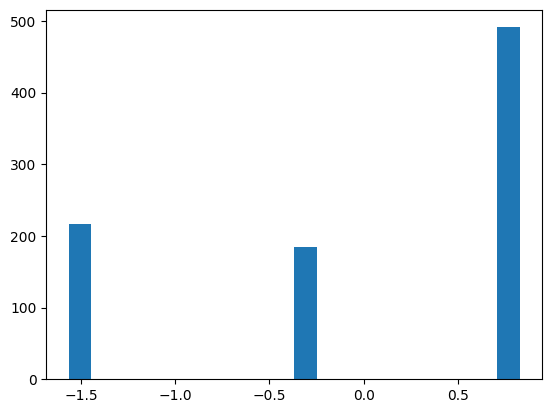

In [47]:
plt.hist(df_scaled[:,1],bins=20)

(array([ 40.,  14.,  15.,  31.,  79.,  98., 262.,  84.,  73.,  45.,  35.,
         35.,  29.,  16.,  13.,  11.,   4.,   5.,   1.,   1.]),
 array([-2.22415608, -1.91837055, -1.61258503, -1.3067995 , -1.00101397,
        -0.69522845, -0.38944292, -0.08365739,  0.22212813,  0.52791366,
         0.83369919,  1.13948471,  1.44527024,  1.75105577,  2.05684129,
         2.36262682,  2.66841235,  2.97419787,  3.2799834 ,  3.58576892,
         3.89155445]),
 <BarContainer object of 20 artists>)

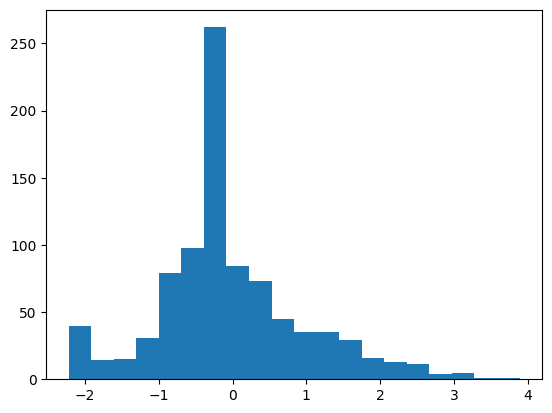

In [48]:
plt.hist(df_scaled[:,2],bins=20)

(array([562., 170.,  67.,  39.,  15.,  16.,   2.,   0.,   9.,   2.,   6.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([-0.64842165, -0.13264224,  0.38313716,  0.89891657,  1.41469598,
         1.93047539,  2.4462548 ,  2.96203421,  3.47781362,  3.99359303,
         4.50937244,  5.02515184,  5.54093125,  6.05671066,  6.57249007,
         7.08826948,  7.60404889,  8.1198283 ,  8.63560771,  9.15138712,
         9.66716653]),
 <BarContainer object of 20 artists>)

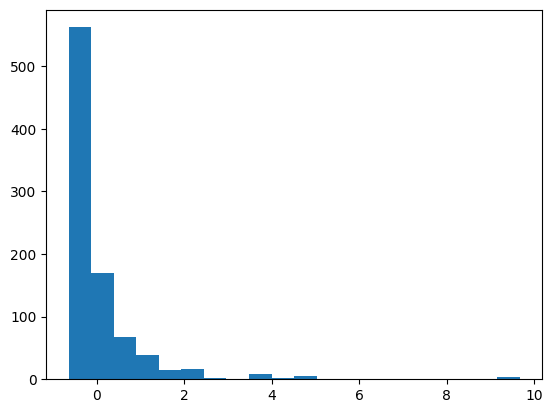

In [49]:
plt.hist(df_scaled[:,3],bins=20)

(array([562., 170.,  67.,  39.,  15.,  16.,   2.,   0.,   9.,   2.,   6.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  25.61646,  51.23292,  76.84938, 102.46584, 128.0823 ,
        153.69876, 179.31522, 204.93168, 230.54814, 256.1646 , 281.78106,
        307.39752, 333.01398, 358.63044, 384.2469 , 409.86336, 435.47982,
        461.09628, 486.71274, 512.3292 ]),
 <BarContainer object of 20 artists>)

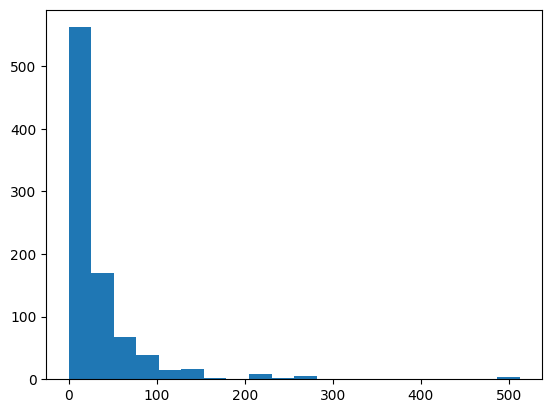

In [50]:
plt.hist(df['Fare'],bins=20)

𝗠𝗶𝗻 𝗠𝗮𝘅 𝗦𝗰𝗮𝗹𝗶𝗻𝗴(###𝗖𝗡𝗡)---𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗧𝗲𝗰𝗵𝗻𝗶𝗾𝘂𝗲𝘀

Min Max Scaling scales the values between 0 to 1. x_scaled=(X -X.min /(X.max - X.min) )

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.33,random_state=42)

In [63]:
from sklearn.preprocessing import MinMaxScaler
min_max=MinMaxScaler()
df_minmax=min_max.fit_transform(x_train)
df_minmax = pd.DataFrame(df_minmax, columns=['Pclass','Age','Fare'])
df_minmax.head()

,Pclass,Age,Fare
0,0.0,0.673285,0.101229
1,1.0,0.346569,0.030254
2,0.5,0.308872,0.081157
3,1.0,0.321438,0.028213
4,1.0,0.271174,0.020527


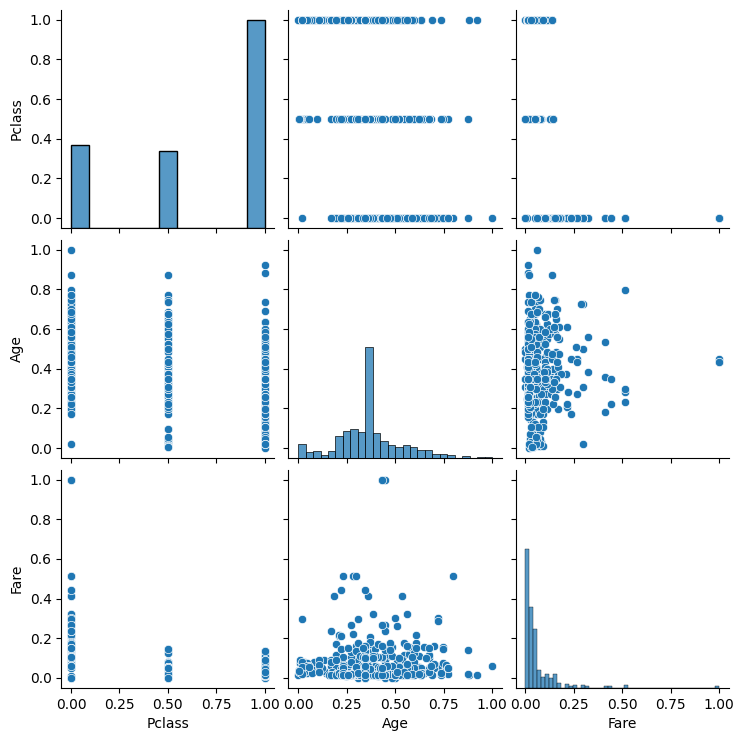

In [64]:
import seaborn as sns
sns.pairplot(df_minmax)

In [65]:
df_minmax.head()

,Pclass,Age,Fare
0,0.0,0.673285,0.101229
1,1.0,0.346569,0.030254
2,0.5,0.308872,0.081157
3,1.0,0.321438,0.028213
4,1.0,0.271174,0.020527


In [66]:
print(df_minmax.columns)

Index(['Pclass', 'Age', 'Fare'], dtype='object')


🚀 Short Answer (interview level)

We plot histograms after scaling to verify distribution, range normalization, and the impact of scaling on each feature.

(array([135.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 125.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 336.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

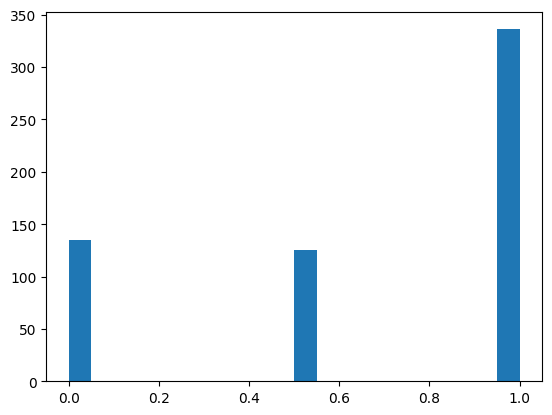

In [67]:

plt.hist(df_minmax['Pclass'], bins=20)

(array([ 29.,   9.,   9.,  23.,  50.,  63., 180.,  56.,  50.,  25.,  24.,
         27.,  16.,  15.,  10.,   5.,   0.,   3.,   1.,   1.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

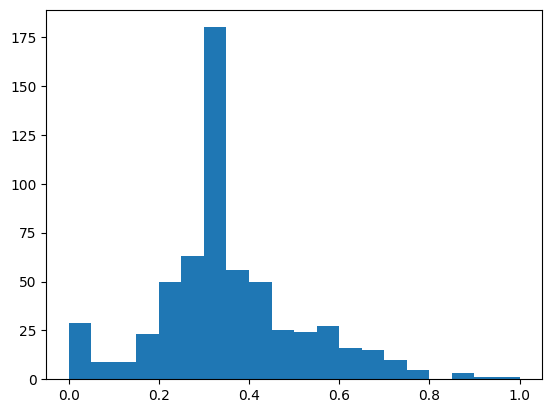

In [68]:
plt.hist(df_minmax['Age'],bins=20)

(array([384., 106.,  51.,  24.,   8.,   9.,   2.,   0.,   5.,   0.,   4.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

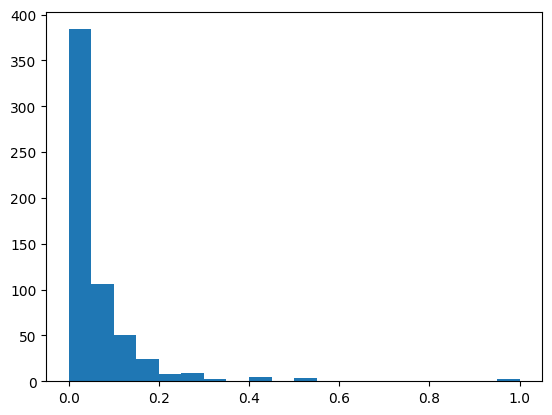

In [69]:
plt.hist(df_minmax['Fare'],bins=20)

𝙍𝙤𝙗𝙪𝙨𝙩 𝙎𝙘𝙖𝙡𝙚𝙧

Robust Scaler are robust to outliers.It is used to scale the feature to median and quantiles Scaling using median and quantiles consists of substracting the median to all the observations, and then dividing by the interquantile difference. The interquantile difference is the difference between the 75th and 25th quantile:

IQR = 75th quantile - 25th quantile

X_scaled = (X - X.median) / IQR

0,1,2,3,4,5,6,7,8,9,10

9-90 percentile---90% of all values in this group is less than 9 1-10 precentile---10% of all values in this group is less than 1 4-40%

In [88]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()


df_robust_scaler=scaler.fit_transform(x_train)
df_robust_scaler = pd.DataFrame(df_robust_scaler, columns=['Pclass','Age','Fare'])
df_robust_scaler.head()

,Pclass,Age,Fare
0,-2.0,2.000000,1.602069
1,0.0,0.000000,0.044788
2,-1.0,-0.230769,1.161670
3,0.0,-0.153846,0.000000
4,0.0,-0.461538,-0.168630


In [ ]:
df_robust_scaler_test=scaler.transform(x_test)

array([[ 0.00000000e+00,  0.00000000e+00,  3.39014989e-02],
       [-1.00000000e+00,  2.30769231e-01, -1.69344754e-01],
       [ 0.00000000e+00, -6.15384615e-01, -2.79623126e-01],
       [-1.00000000e+00, -1.69230769e+00,  7.94252677e-01],
       [ 0.00000000e+00, -1.07692308e+00, -1.37580300e-01],
       [-2.00000000e+00, -1.53846154e-01,  2.75785011e+00],
       [ 0.00000000e+00,  0.00000000e+00, -2.87117773e-01],
       [ 0.00000000e+00, -9.23076923e-01,  1.51854390e-01],
       [ 0.00000000e+00, -9.23076923e-01, -2.87117773e-01],
       [-2.00000000e+00, -6.92307692e-01,  5.06599572e-01],
       [-2.00000000e+00,  6.92307692e-01,  1.65506638e+00],
       [ 0.00000000e+00,  1.23076923e+00, -2.74269807e-01],
       [ 0.00000000e+00,  0.00000000e+00,  4.71627409e-01],
       [ 0.00000000e+00,  1.53846154e-01, -3.09601713e-01],
       [-1.00000000e+00,  6.15384615e-01, -6.22783726e-02],
       [-2.00000000e+00, -9.23076923e-01,  1.06834261e+00],
       [-2.00000000e+00,  1.07692308e+00

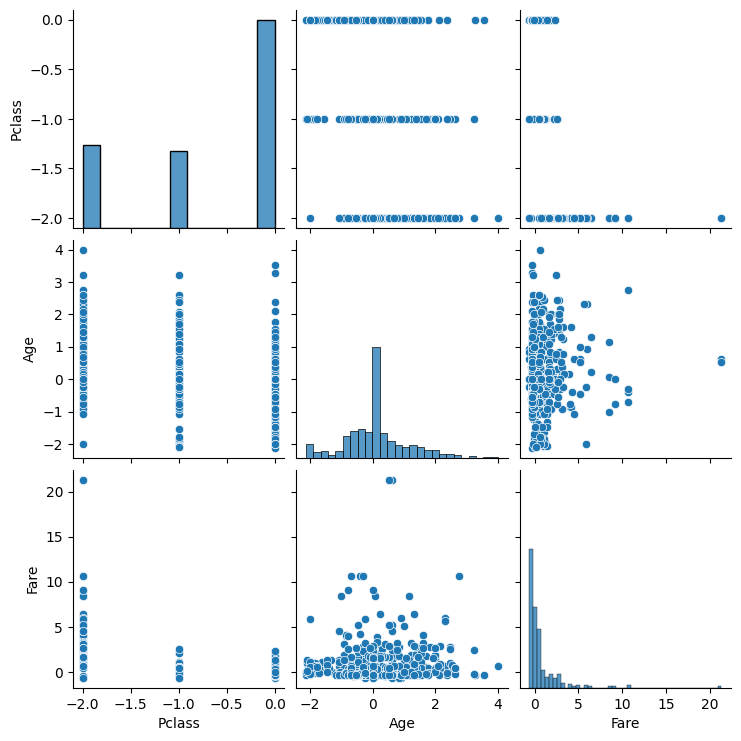

In [92]:
import seaborn as sns 
sns.pairplot(df_robust_scaler)

🔵 Blue → StandardScaler

🟠 Orange → MinMaxScaler

🟢 Green → RobustScaler

(array([[140., 155.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [ 36., 170.,  68.,  19.,   2.,   0.,   0.,   0.,   0.,   0.],
        [  0., 176.,  72.,  20.,  10.,   5.,   4.,   0.,   4.,   4.]]),
 array([-2.09      , -0.81924069,  0.45151863,  1.72227794,  2.99303726,
         4.26379657,  5.53455589,  6.8053152 ,  8.07607452,  9.34683383,
        10.61759315]),
 <a list of 3 BarContainer objects>)

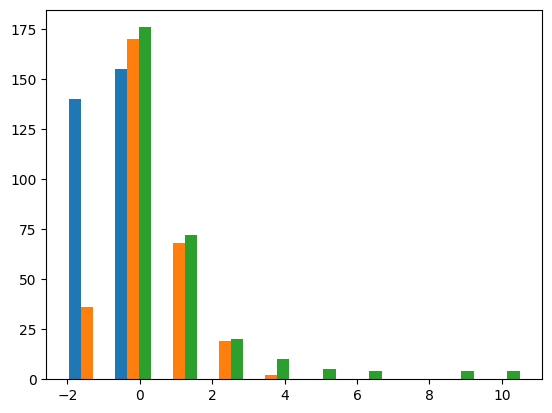

In [91]:
import seaborn as sns
df_robust_scaler_test=pd.DataFrame(scaler.transform(x_test))
plt.hist(df_robust_scaler_test)

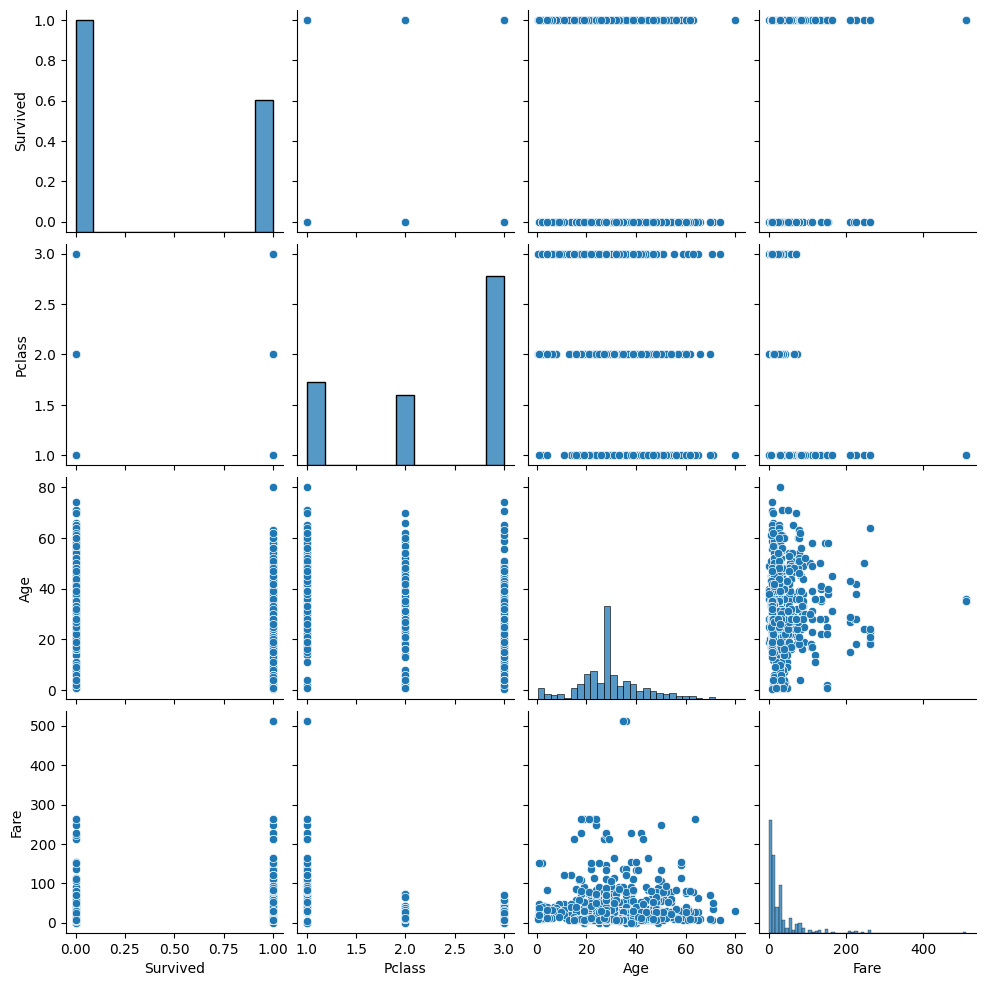

In [93]:
import seaborn as sns
sns.pairplot(df)

(array([ 29.,   9.,   9.,  23.,  50.,  63., 180.,  56.,  50.,  25.,  24.,
         27.,  16.,  15.,  10.,   5.,   0.,   3.,   1.,   1.]),
 array([-2.12153846, -1.81546154, -1.50938462, -1.20330769, -0.89723077,
        -0.59115385, -0.28507692,  0.021     ,  0.32707692,  0.63315385,
         0.93923077,  1.24530769,  1.55138462,  1.85746154,  2.16353846,
         2.46961538,  2.77569231,  3.08176923,  3.38784615,  3.69392308,
         4.        ]),
 <BarContainer object of 20 artists>)

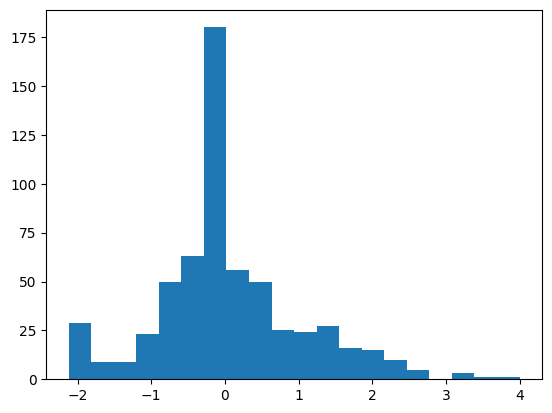

In [94]:
plt.hist(df_robust_scaler['Age'],bins=20)

(array([384., 106.,  51.,  24.,   8.,   9.,   2.,   0.,   5.,   0.,   4.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.]),
 array([-0.61902355,  0.47804111,  1.57510578,  2.67217045,  3.76923512,
         4.86629979,  5.96336445,  7.06042912,  8.15749379,  9.25455846,
        10.35162313, 11.44868779, 12.54575246, 13.64281713, 14.7398818 ,
        15.83694647, 16.93401113, 18.0310758 , 19.12814047, 20.22520514,
        21.32226981]),
 <BarContainer object of 20 artists>)

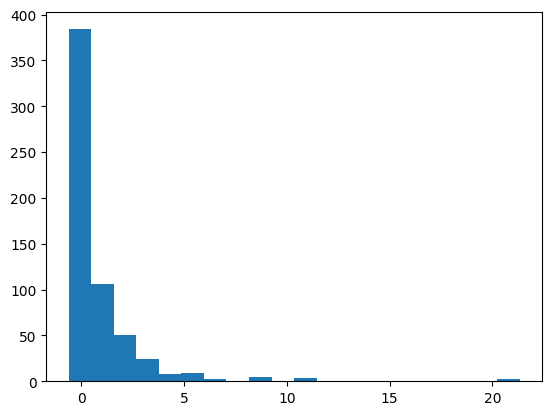

In [95]:
plt.hist(df_robust_scaler['Fare'],bins=20)

𝙂𝙪𝙖𝙨𝙨𝙞𝙖𝙣 𝙏𝙧𝙖𝙣𝙨𝙛𝙤𝙧𝙢𝙖𝙩𝙞𝙤𝙣

Some machine learning algorithms like linear and logistic assume that the features are normally distributed -Accuracy -Performance

1. logarithmic transformation
2. reciprocal transformation
3. square root transformation
4. exponential transformation (more general, you can use any  exponent)
5. boxcox transformation

In [97]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [98]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [99]:
### fillna
df['Age']=df['Age'].fillna(df['Age'].median())

In [100]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [101]:
import matplotlib.pyplot as plt

In [102]:
import scipy.stats as stat 
import pylab

In [105]:
### If you want to check whether feature is guassian or normal distributed
### Q-Q plot
def plot_data(df,feature):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    plt.show()

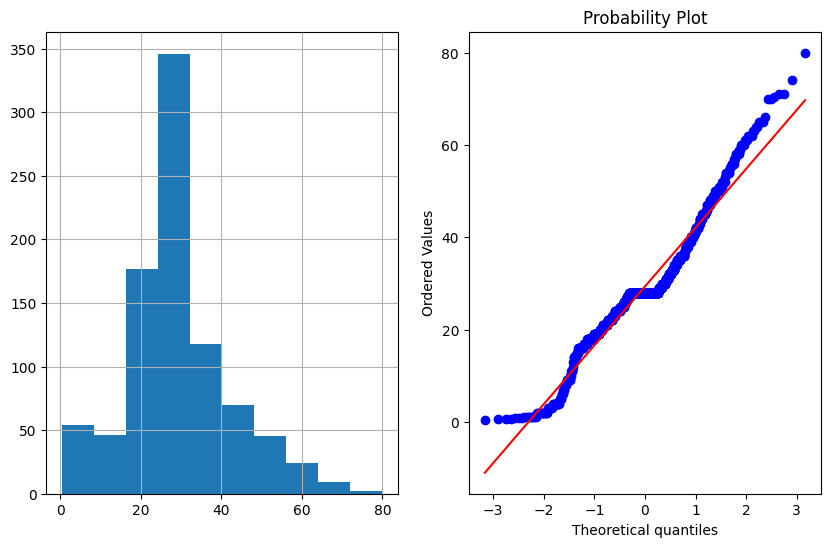

In [106]:
plot_data(df,'Age')

1. Logarithmic Transformation

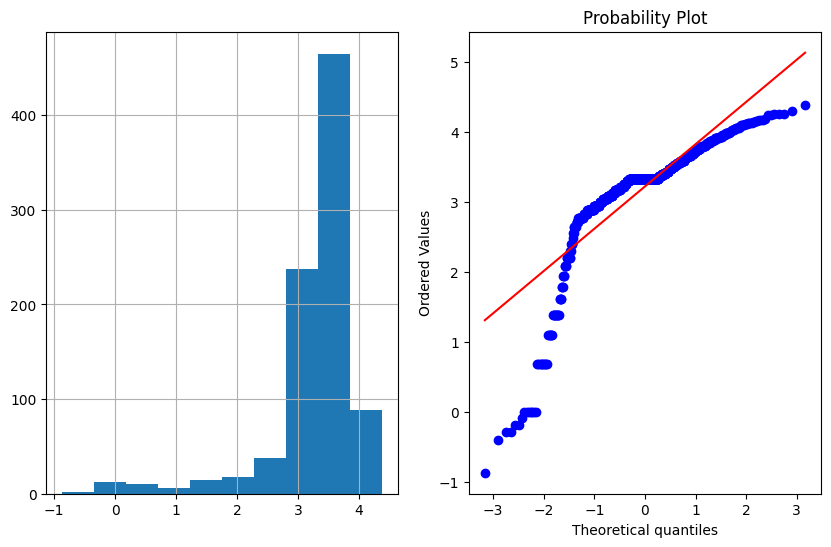

In [108]:
import numpy as np
df['Age_log']=np.log(df['Age'])
plot_data(df,'Age_log')

2. Reciprocal Trnasformation

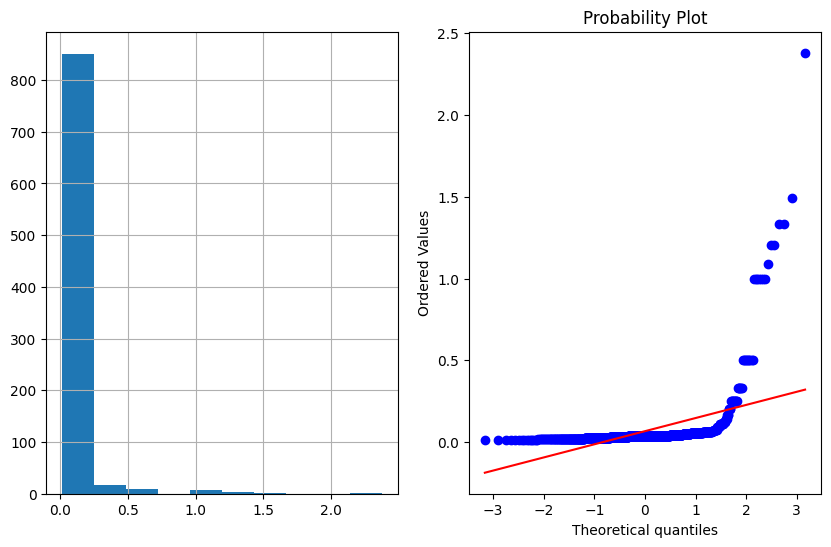

In [109]:
df['Age_reciprocal']=1/df.Age 
plot_data(df,'Age_reciprocal')

3. Square Root Transformation


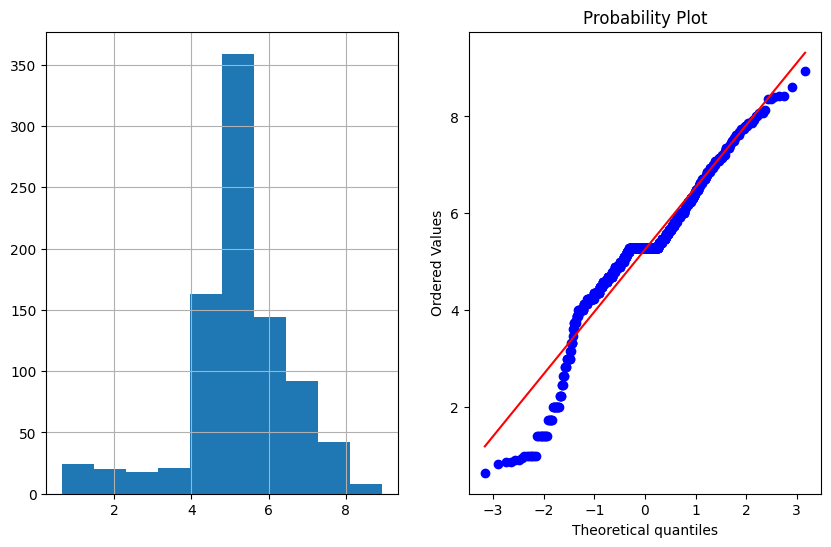

In [110]:
df['Age_sqaure']=df.Age**(1/2)
plot_data(df,'Age_sqaure')

4. Exponential Transformation

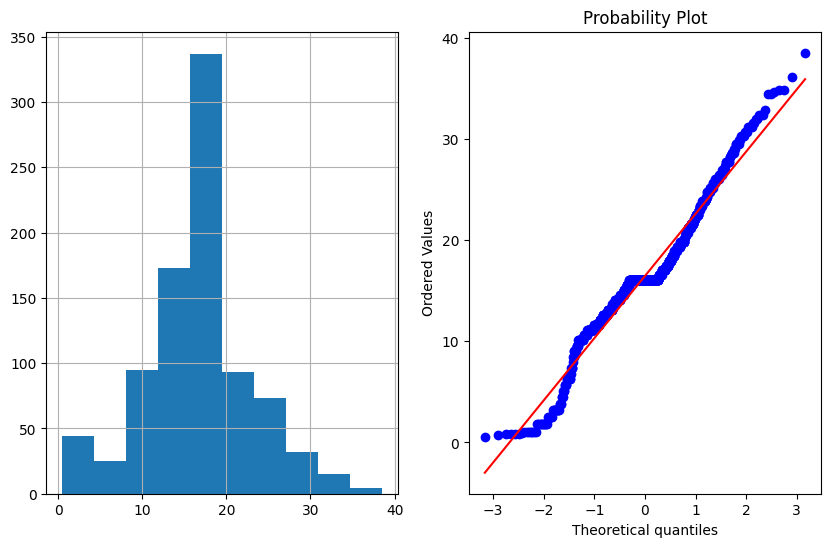

In [111]:
df['Age_exponential']=df.Age**(1/1.2)
plot_data(df,'Age_exponential')


5. BoxCOx Transformation

The Box-Cox transformation is defined as:

T(Y)=(Y exp(λ)−1)/λ

where Y is the response variable and λ is the transformation parameter. λ varies from -5 to 5. In the transformation, all values of λ are considered and the optimal value for a given variable is selected.

In [112]:
df['Age_Boxcox'],parameters=stat.boxcox(df['Age'])

In [113]:
print(parameters)

0.796453194094064


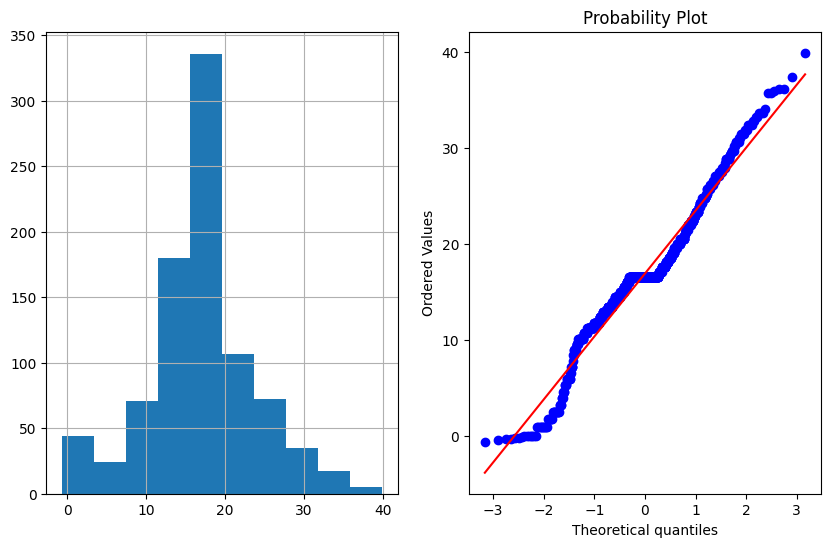

In [114]:
plot_data(df,'Age_Boxcox')

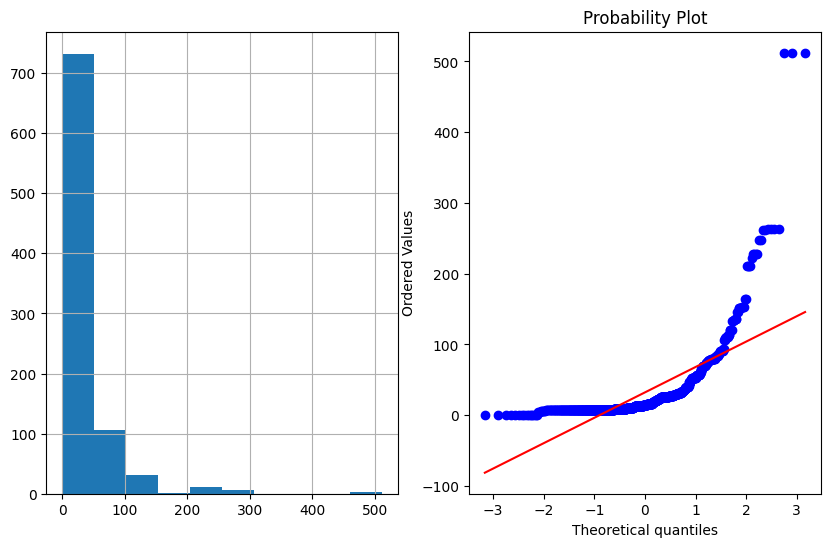

In [115]:
plot_data(df,'Fare')

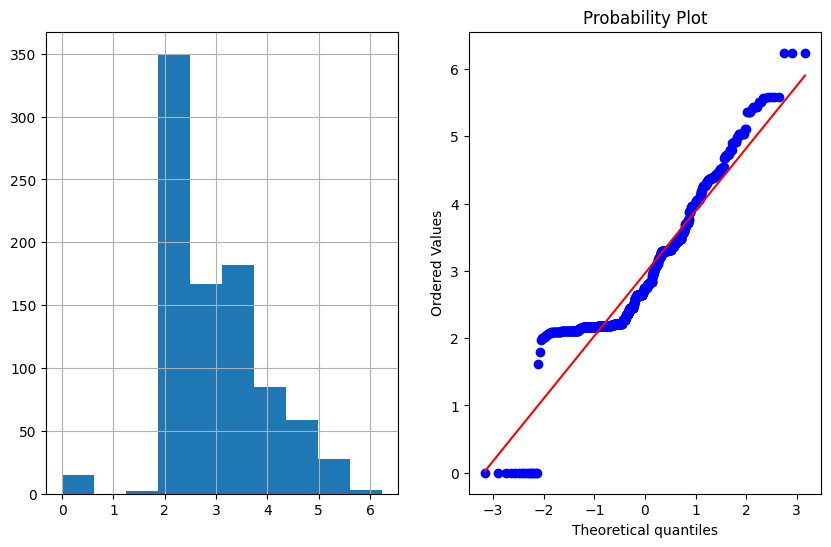

In [117]:
#### Fare
df['Fare_log']=np.log1p(df['Fare'])
plot_data(df,'Fare_log')

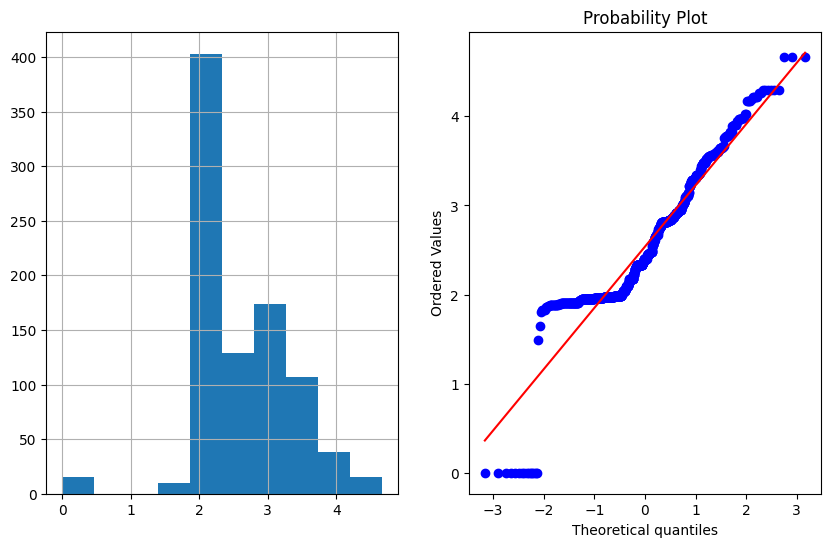

In [118]:
df['Fare_Boxcox'],parameters=stat.boxcox(df['Fare']+1)
plot_data(df,'Fare_Boxcox')